# Football Video Analysis Pipeline

This notebook processes the entire video, applies the complete football analytics pipeline, and saves annotated frames to an output video.

**Pipeline Steps:**
- Player & object detection
- Player tracking with ByteTrack
- Team classification via SigLIP embeddings
- Goalkeeper assignment
- Field keypoint detection
- Homography transformation to pitch space
- Frame annotation and video export

---

## Section 1: Setup & Dependencies

In [1]:
import sys
import subprocess

# Install required packages
packages = [
    "supervision",
    "opencv-python",
    "numpy",
    "torch",
    "ultralytics",
    "transformers",
    "umap-learn",
    "scikit-learn",
    "tqdm",
    "more-itertools",
    "plotly"
]

for package in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", package]
    )

print("✓ All required packages installed!")

✓ All required packages installed!


## Section 2: Core Imports

In [2]:
# Standard Library
from pathlib import Path

# Computer Vision & ML
import torch
import cv2
import numpy as np
from tqdm import tqdm
from more_itertools import chunked

# Detection & Tracking
import supervision as sv
from ultralytics import YOLO

# Embeddings & Clustering
from transformers import AutoProcessor, AutoModel
import umap
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
from sports.configs.soccer import SoccerPitchConfiguration
from sports.annotators.soccer import draw_pitch, draw_points_on_pitch
from sports.common.view import ViewTransformer

print("✓ All imports successful!")

✓ All imports successful!


## Section 3: Global Configuration & Constants

In [3]:
# Device Management
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Device: {DEVICE}")
    print(f"GPU: {gpu_name}")
else:
    print(f"Device: {DEVICE}")

# Project Paths
PROJECT_DIR = Path("d:/football_main")
VIDEO_PATH = PROJECT_DIR / "sample.mp4"
PLAYER_MODEL_PATH = PROJECT_DIR / "best.pt"
FIELD_MODEL_PATH = PROJECT_DIR / "updatedkeypoints.pt"
OUTPUT_DIR = PROJECT_DIR / "output_videos"
OUTPUT_DIR.mkdir(exist_ok=True)

# Detection Parameters
DETECTION_CONFIDENCE = 0.30
NMS_THRESHOLD = 0.5

# Class IDs
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

# Embedding Parameters
BATCH_SIZE = 32
SIGLIP_MODEL_PATH = "google/siglip-base-patch16-224"

# Color Scheme
COLOR_TEAM_0 = "#0066FF"  # Bright Blue
COLOR_TEAM_1 = "#FF0000"  # Bright Red
COLOR_REFEREE = "#FFFF00"  # Yellow

# Video Parameters
STRIDE = 1  # Process every frame

print(f"✓ Configuration loaded!")
print(f"Video: {VIDEO_PATH}")
print(f"Video exists: {VIDEO_PATH.exists()}")
print(f"Output folder: {OUTPUT_DIR}")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
✓ Configuration loaded!
Video: d:\football_main\sample.mp4
Video exists: True
Output folder: d:\football_main\output_videos


## Section 4: Load Models & Initialize Components

In [4]:
print("Loading YOLO Models...")
PLAYER_DETECTION_MODEL = YOLO(str(PLAYER_MODEL_PATH))
print(f"Player Model Task: {PLAYER_DETECTION_MODEL.task}")
print(f"Player Model Classes: {PLAYER_DETECTION_MODEL.names}")

FIELD_DETECTION_MODEL = YOLO(str(FIELD_MODEL_PATH))
print(f"Field Model Task: {FIELD_DETECTION_MODEL.task}")

print("\nLoading SigLIP Embeddings Model...")
EMBEDDINGS_PROCESSOR = AutoProcessor.from_pretrained(SIGLIP_MODEL_PATH)
EMBEDDINGS_MODEL = AutoModel.from_pretrained(SIGLIP_MODEL_PATH).to(DEVICE)

print("\nInitializing Clustering Models...")
REDUCER = umap.UMAP(n_components=3)
CLUSTERING_MODEL = KMeans(n_clusters=2, random_state=42)

print("\nInitializing Pitch Configuration...")
PITCH_CONFIG = SoccerPitchConfiguration()

print("\n✓ All models loaded successfully!")

Loading YOLO Models...
Player Model Task: detect
Player Model Classes: {0: 'ball', 1: 'goalkeeper', 2: 'player', 3: 'referee'}
Field Model Task: pose

Loading SigLIP Embeddings Model...


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]


Initializing Clustering Models...

Initializing Pitch Configuration...

✓ All models loaded successfully!


## Section 5: Utility Functions

In [16]:
def get_video_properties(video_path):
    """Get video properties like FPS, frame count, width, height."""
    cap = cv2.VideoCapture(str(video_path))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    
    return {
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height
    }

def initialize_tracker():
    """Initialize ByteTrack for object tracking."""
    from supervision import ByteTrack
    return ByteTrack()

def create_annotators():
    """Create annotation objects for visualization."""
    annotators = {
        "box": sv.BoxAnnotator(thickness=3),
        "label": sv.LabelAnnotator(text_thickness=2, text_scale=0.7),
        "triangle": sv.TriangleAnnotator(color=sv.Color.from_hex("#FFD700"), base=10, height=10),
        "mask": sv.MaskAnnotator()
    }
    return annotators

def detect_objects(frame, model, conf=DETECTION_CONFIDENCE):
    """Detect objects in frame using YOLO model."""
    results = model(frame, conf=conf, device=DEVICE)
    detections = sv.Detections.from_ultralytics(results[0])
    return detections

def filter_detections_by_class(detections, class_id):
    """Filter detections by class ID."""
    if len(detections) == 0:
        return detections
    
    if detections.class_id is None or len(detections.class_id) == 0:
        return detections
    
    # Handle the case where mask and detections length might differ
    try:
        mask = detections.class_id == class_id
        if len(mask) != len(detections.xyxy):
            # Return empty if sizes don't match
            return sv.Detections.empty()
        return detections[mask]
    except:
        return sv.Detections.empty()

def enlarge_bounding_boxes(detections, padding=10):
    """Enlarge bounding boxes by padding."""
    if len(detections) == 0:
        return detections
    
    xyxy = detections.xyxy.copy()
    xyxy[:, 0] = np.maximum(xyxy[:, 0] - padding, 0)
    xyxy[:, 1] = np.maximum(xyxy[:, 1] - padding, 0)
    xyxy[:, 2] = xyxy[:, 2] + padding
    xyxy[:, 3] = xyxy[:, 3] + padding
    
    detections.xyxy = xyxy
    return detections

def apply_nms(detections, nms_threshold=NMS_THRESHOLD):
    """Apply Non-Maximum Suppression."""
    if len(detections) == 0:
        return detections
    return detections.with_nms(threshold=nms_threshold)

def track_detections(tracker, detections):
    """Update tracker with detections while preserving original class_id."""
    if len(detections) == 0:
        return detections
    
    # Store original class IDs before tracking
    original_class_id = detections.class_id.copy() if detections.class_id is not None else None
    
    # Apply tracking (this adds tracker_id)
    tracked = tracker.update_with_detections(detections)
    
    # Restore original class IDs
    if original_class_id is not None and len(original_class_id) == len(tracked):
        tracked.class_id = original_class_id
    
    return tracked

def extract_crops(frame, detections):
    """Extract image crops from detections."""
    crops = []
    for xyxy in detections.xyxy:
        x1, y1, x2, y2 = xyxy.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        crop = frame[y1:y2, x1:x2]
        if crop.size > 0:
            crops.append(crop)
    return crops

def classify_player_teams(embeddings, reducer, clustering_model, fit=False):
    """Classify players into teams using embeddings."""
    if len(embeddings) == 0:
        return []
    
    if fit or len(embeddings) > 1:
        try:
            reduced = reducer.fit_transform(embeddings)
            clustering_model.fit(reduced)
            team_ids = clustering_model.labels_.tolist()
        except:
            team_ids = [0] * len(embeddings)
    else:
        team_ids = [0]
    
    return team_ids

def resolve_goalkeepers_team_id(players_detections, goalkeepers_detections):
    """Assign goalkeepers to nearest team based on player positions."""
    goalkeeper_team_ids = []
    
    for gk_xyxy in goalkeepers_detections.xyxy:
        gk_center = ((gk_xyxy[0] + gk_xyxy[2]) / 2, (gk_xyxy[1] + gk_xyxy[3]) / 2)
        
        min_distance = float('inf')
        nearest_team = 0
        
        for player_idx, player_xyxy in enumerate(players_detections.xyxy):
            player_center = ((player_xyxy[0] + player_xyxy[2]) / 2, (player_xyxy[1] + player_xyxy[3]) / 2)
            distance = np.sqrt((gk_center[0] - player_center[0])**2 + (gk_center[1] - player_center[1])**2)
            
            if distance < min_distance:
                min_distance = distance
                nearest_team = int(players_detections.class_id[player_idx])
        
        goalkeeper_team_ids.append(nearest_team)
    
    return goalkeeper_team_ids

def get_color_for_team(team_id):
    """Get color for team ID."""
    if team_id == 0:
        return sv.Color.from_hex(COLOR_TEAM_0)  # Blue
    elif team_id == 1:
        return sv.Color.from_hex(COLOR_TEAM_1)  # Red
    else:
        return sv.Color.from_hex(COLOR_REFEREE)  # Yellow

def annotate_frame_with_colors(frame, detections, label_annotator):
    """
    Annotate frame with colored boxes per team and tracking IDs.
    """
    annotated_frame = frame.copy()
    
    if len(detections) == 0:
        return annotated_frame
    
    # Draw each detection with team-specific color
    for idx, xyxy in enumerate(detections.xyxy):
        x1, y1, x2, y2 = xyxy.astype(int)
        
        # Get team color
        team_id = int(detections.class_id[idx]) if detections.class_id is not None else 0
        color = get_color_for_team(team_id)
        
        # Convert color to BGR for OpenCV
        color_bgr = (int(color.b * 255), int(color.g * 255), int(color.r * 255))
        
        # Draw box
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color_bgr, 3)
        
        # Draw tracker ID and team label
        if detections.tracker_id is not None and len(detections.tracker_id) > idx:
            tracker_id = int(detections.tracker_id[idx])
            label = f"ID:{tracker_id} T:{team_id}"
        else:
            label = f"T:{team_id}"
        
        # Draw label background and text
        text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
        text_x, text_y = x1, y1 - 10
        
        # Background
        cv2.rectangle(
            annotated_frame,
            (text_x - 5, text_y - text_size[1] - 5),
            (text_x + text_size[0] + 5, text_y + 5),
            color_bgr,
            -1
        )
        
        # Text
        cv2.putText(
            annotated_frame,
            label,
            (text_x, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )
    
    return annotated_frame

def extract_embeddings(crops, model, processor, device=DEVICE, batch_size=BATCH_SIZE):
    """Extract embeddings from image crops using SigLIP vision model."""
    if not crops:
        return np.array([])
    
    pil_crops = [sv.cv2_to_pillow(crop) for crop in crops]
    embeddings_list = []
    model.eval()
    
    with torch.no_grad():
        for batch in chunked(pil_crops, batch_size):
            inputs = processor(images=list(batch), return_tensors="pt").to(device)
            
            if hasattr(model, 'vision_model'):
                vision_outputs = model.vision_model(pixel_values=inputs['pixel_values'])
                batch_embeddings = vision_outputs.pooler_output.cpu().numpy()
            else:
                outputs = model(pixel_values=inputs['pixel_values'], input_ids=None)
                batch_embeddings = outputs.image_embeds.cpu().numpy()
            
            embeddings_list.append(batch_embeddings)
            
            if device == "cuda":
                torch.cuda.empty_cache()
    
    return np.concatenate(embeddings_list)

## Section 6: Video Processing Pipeline

In [17]:
# Get video properties
video_props = get_video_properties(VIDEO_PATH)
print("Video Properties:")
print(f"  FPS: {video_props['fps']}")
print(f"  Frame Count: {video_props['frame_count']}")
print(f"  Resolution: {video_props['width']}x{video_props['height']}")

# Create output video file using XVID codec (more stable than mp4v)
output_file = OUTPUT_DIR / "annotated_video.avi"
writer = cv2.VideoWriter(
    str(output_file),
    cv2.VideoWriter_fourcc(*'XVID'),
    video_props["fps"],
    (video_props["width"], video_props["height"])
)

if not writer.isOpened():
    print("❌ Warning: Video writer failed to open, trying with MJPG codec...")
    output_file = OUTPUT_DIR / "annotated_video.avi"
    writer = cv2.VideoWriter(
        str(output_file),
        cv2.VideoWriter_fourcc(*'MJPG'),
        video_props["fps"],
        (video_props["width"], video_props["height"])
    )

if writer.isOpened():
    print(f"✓ Video writer initialized successfully!")
    print(f"  Output: {output_file.name}")
else:
    print("❌ Error: Could not initialize video writer!")

Video Properties:
  FPS: 25
  Frame Count: 750
  Resolution: 1920x1080
✓ Video writer initialized successfully!
  Output: annotated_video.avi


## Section 7: Main Video Processing Loop

In [18]:
print("Starting video processing...")
print("=" * 80)

# Initialize tracker
tracker = initialize_tracker()

# Maintain player ID -> team ID mapping for consistency
player_team_mapping = {}
clustering_fitted = False
frame_count = 0

# Open video
cap = cv2.VideoCapture(str(VIDEO_PATH))

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        # Print progress every 30 frames
        if frame_count % 30 == 0:
            print(f"Processing frame {frame_count}/{video_props['frame_count']}")
        
        annotated_frame = frame.copy()
        
        # ================================================================
        # STEP 1: Detect all objects (players, goalkeepers, referees, ball)
        # ================================================================
        detections = detect_objects(frame, PLAYER_DETECTION_MODEL)
        
        # ================================================================
        # STEP 2: Separate ball from other objects
        # ================================================================
        ball_mask = detections.class_id == BALL_ID
        non_ball_mask = detections.class_id != BALL_ID
        
        ball_detections = detections[ball_mask] if ball_mask.sum() > 0 else sv.Detections.empty()
        non_ball_detections = detections[non_ball_mask] if non_ball_mask.sum() > 0 else sv.Detections.empty()
        
        non_ball_detections = apply_nms(non_ball_detections)
        
        # ================================================================
        # STEP 3: Track detections
        # ================================================================
        tracked_detections = track_detections(tracker, non_ball_detections)
        
        # ================================================================
        # STEP 4: Separate object types
        # ================================================================
        if len(tracked_detections) > 0 and tracked_detections.class_id is not None:
            goalkeepers_mask = tracked_detections.class_id == GOALKEEPER_ID
            players_mask = tracked_detections.class_id == PLAYER_ID
            referees_mask = tracked_detections.class_id == REFEREE_ID
            
            goalkeepers_detections = tracked_detections[goalkeepers_mask] if goalkeepers_mask.sum() > 0 else sv.Detections.empty()
            players_detections = tracked_detections[players_mask] if players_mask.sum() > 0 else sv.Detections.empty()
            referees_detections = tracked_detections[referees_mask] if referees_mask.sum() > 0 else sv.Detections.empty()
        else:
            goalkeepers_detections = sv.Detections.empty()
            players_detections = sv.Detections.empty()
            referees_detections = sv.Detections.empty()
        
        # ================================================================
        # STEP 5: Classify players into teams using embeddings
        # ================================================================
        if len(players_detections) > 0:
            player_crops = extract_crops(frame, players_detections)
            
            # Debug: print number of players detected
            if frame_count == 1:
                print(f"Frame 1: {len(players_detections)} players detected")
            
            embeddings = extract_embeddings(
                player_crops,
                EMBEDDINGS_MODEL,
                EMBEDDINGS_PROCESSOR,
                device=DEVICE
            )
            
            # Debug: check embeddings shape
            if frame_count == 1:
                print(f"Embeddings shape: {embeddings.shape}")
            
            # Process each player with TEAM CLASSIFICATION
            team_ids = []
            for idx, tracker_id in enumerate(players_detections.tracker_id):
                tracker_id = int(tracker_id)
                
                # If we've seen this player before, use cached team assignment
                if tracker_id in player_team_mapping:
                    team_ids.append(player_team_mapping[tracker_id])
                else:
                    # New player: classify and cache
                    if len(embeddings) > idx:
                        # IMPORTANT: Fit on ALL players in first frame, then use for subsequent frames
                        if not clustering_fitted and len(embeddings) > 1:
                            # Fit UMAP reducer on all player embeddings
                            try:
                                reduced = REDUCER.fit_transform(embeddings)
                                CLUSTERING_MODEL.fit(reduced)
                                clustering_fitted = True
                                # Get team assignments for all players
                                all_team_ids = CLUSTERING_MODEL.labels_.tolist()
                                for i, team in enumerate(all_team_ids):
                                    tid = int(players_detections.tracker_id[i])
                                    player_team_mapping[tid] = team
                                    if i == idx:
                                        team_ids.append(team)
                            except Exception as e:
                                if frame_count == 1:
                                    print(f"Error fitting clustering: {e}")
                                team_ids.append(0)
                        else:
                            # For new players after initial fit, use the fitted model
                            if clustering_fitted:
                                try:
                                    single_embedding = embeddings[idx:idx+1]
                                    reduced = REDUCER.transform(single_embedding)
                                    team_id = CLUSTERING_MODEL.predict(reduced)[0]
                                    team_ids.append(team_id)
                                    player_team_mapping[tracker_id] = team_id
                                except:
                                    team_ids.append(0)
                            else:
                                team_ids.append(0)
                    else:
                        team_ids.append(0)
            
            if frame_count == 1:
                print(f"Team IDs for frame 1: {team_ids}")
            
            players_detections.class_id = np.array(team_ids, dtype=int)
        
        # ================================================================
        # STEP 6: Assign goalkeepers to nearest team
        # ================================================================
        if len(goalkeepers_detections) > 0 and len(players_detections) > 0:
            goalkeeper_team_ids = resolve_goalkeepers_team_id(
                players_detections,
                goalkeepers_detections
            )
            goalkeepers_detections.class_id = np.array(goalkeeper_team_ids, dtype=int)
        
        # ================================================================
        # STEP 7: Set referee team (always team 2)
        # ================================================================
        if len(referees_detections) > 0:
            referees_detections.class_id = np.full(len(referees_detections), 2, dtype=int)
        
        # ================================================================
        # STEP 8: Merge all player detections (players + goalkeepers + referees)
        # ================================================================
        all_detections_list = []
        if len(players_detections) > 0:
            all_detections_list.append(players_detections)
        if len(goalkeepers_detections) > 0:
            all_detections_list.append(goalkeepers_detections)
        if len(referees_detections) > 0:
            all_detections_list.append(referees_detections)
        
        if all_detections_list:
            all_detections = sv.Detections.merge(all_detections_list)
        else:
            all_detections = sv.Detections.empty()
        
        # ================================================================
        # STEP 9: Annotate frame with player detection boxes
        # ================================================================
        # Draw detections with colors based on team and tracking ID labels
        for idx, xyxy in enumerate(all_detections.xyxy):
            x1, y1, x2, y2 = xyxy.astype(int)
            
            # Get team color
            team_id = int(all_detections.class_id[idx]) if all_detections.class_id is not None else 0
            color = get_color_for_team(team_id)
            
            # Convert color to BGR for OpenCV
            color_bgr = (int(color.b * 255), int(color.g * 255), int(color.r * 255))
            
            # Draw thick box
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color_bgr, 3)
            
            # Get tracking ID and team label
            tracker_id = int(all_detections.tracker_id[idx]) if all_detections.tracker_id is not None else -1
            team_name = "T0" if team_id == 0 else "T1" if team_id == 1 else "REF"
            label = f"ID:{tracker_id} {team_name}"
            
            # Draw label with background
            text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.75, 2)[0]
            text_x, text_y = x1, y1 - 10
            
            # Background rectangle
            cv2.rectangle(
                annotated_frame,
                (text_x - 5, text_y - text_size[1] - 5),
                (text_x + text_size[0] + 5, text_y + 5),
                color_bgr,
                -1
            )
            
            # White text
            cv2.putText(
                annotated_frame,
                label,
                (text_x, text_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75,
                (255, 255, 255),
                2
            )
        
        # ================================================================
        # STEP 10: Annotate ball
        # ================================================================
        if len(ball_detections) > 0:
            for xyxy in ball_detections.xyxy:
                x1, y1, x2, y2 = xyxy.astype(int)
                cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                # Draw yellow circle for ball
                cv2.circle(annotated_frame, (cx, cy), 8, (0, 255, 255), 3)
                cv2.putText(
                    annotated_frame,
                    "BALL",
                    (cx - 20, cy - 15),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 255),
                    2
                )
        
        # ================================================================
        # STEP 11: Write frame to output video
        # ================================================================
        writer.write(annotated_frame)

finally:
    cap.release()
    writer.release()
    print("\n" + "=" * 80)
    print(f"✓ Video processing complete!")
    print(f"Total frames processed: {frame_count}")
    print(f"Output video saved to: {output_file}")
    print(f"Clustering fitted: {clustering_fitted}")
    print(f"Total players tracked: {len(player_team_mapping)}")

Starting video processing...

0: 384x640 1 ball, 1 goalkeeper, 20 players, 3 referees, 31.7ms
Speed: 8.0ms preprocess, 31.7ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)
Frame 1: 20 players detected
Embeddings shape: (20, 768)
Team IDs for frame 1: [0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1]

0: 384x640 1 ball, 1 goalkeeper, 20 players, 3 referees, 31.9ms
Speed: 4.4ms preprocess, 31.9ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 balls, 1 goalkeeper, 20 players, 3 referees, 8.5ms
Speed: 1.9ms preprocess, 8.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 ball, 1 goalkeeper, 21 players, 3 referees, 8.7ms
Speed: 2.2ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 ball, 1 goalkeeper, 20 players, 3 referees, 9.4ms
Speed: 2.2ms preprocess, 9.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 ball, 1 goal

In [8]:
# Initialize keypoint annotators
edge_annotator = sv.EdgeAnnotator(
    color=sv.Color.from_hex("#00BFFF"),
    thickness=2,
    edges=PITCH_CONFIG.edges
)

vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex("#FFD700"),
    radius=6
)


## Section 8: Summary & Statistics

In [19]:
# Check if output file exists and show file size
if output_file.exists():
    file_size_mb = output_file.stat().st_size / (1024 * 1024)
    print("\n📊 Output Video Summary:")
    print(f"  File: {output_file.name}")
    print(f"  Size: {file_size_mb:.2f} MB")
    print(f"  Duration: {frame_count / video_props['fps']:.2f} seconds")
    print(f"  Resolution: {video_props['width']}x{video_props['height']}")
    print(f"  FPS: {video_props['fps']}")
    print(f"  Total Frames: {frame_count}")
else:
    print("❌ Output file was not created!")


📊 Output Video Summary:
  File: annotated_video.avi
  Size: 75.98 MB
  Duration: 30.00 seconds
  Resolution: 1920x1080
  FPS: 25
  Total Frames: 750


## Section 9: Field Keypoint Visualization on Sample Frame


0: 384x640 1 pitch, 275.0ms
Speed: 5.7ms preprocess, 275.0ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)
Detected keypoints shape: (1, 32, 2)
Filtered keypoints (confidence > 0.5): 8


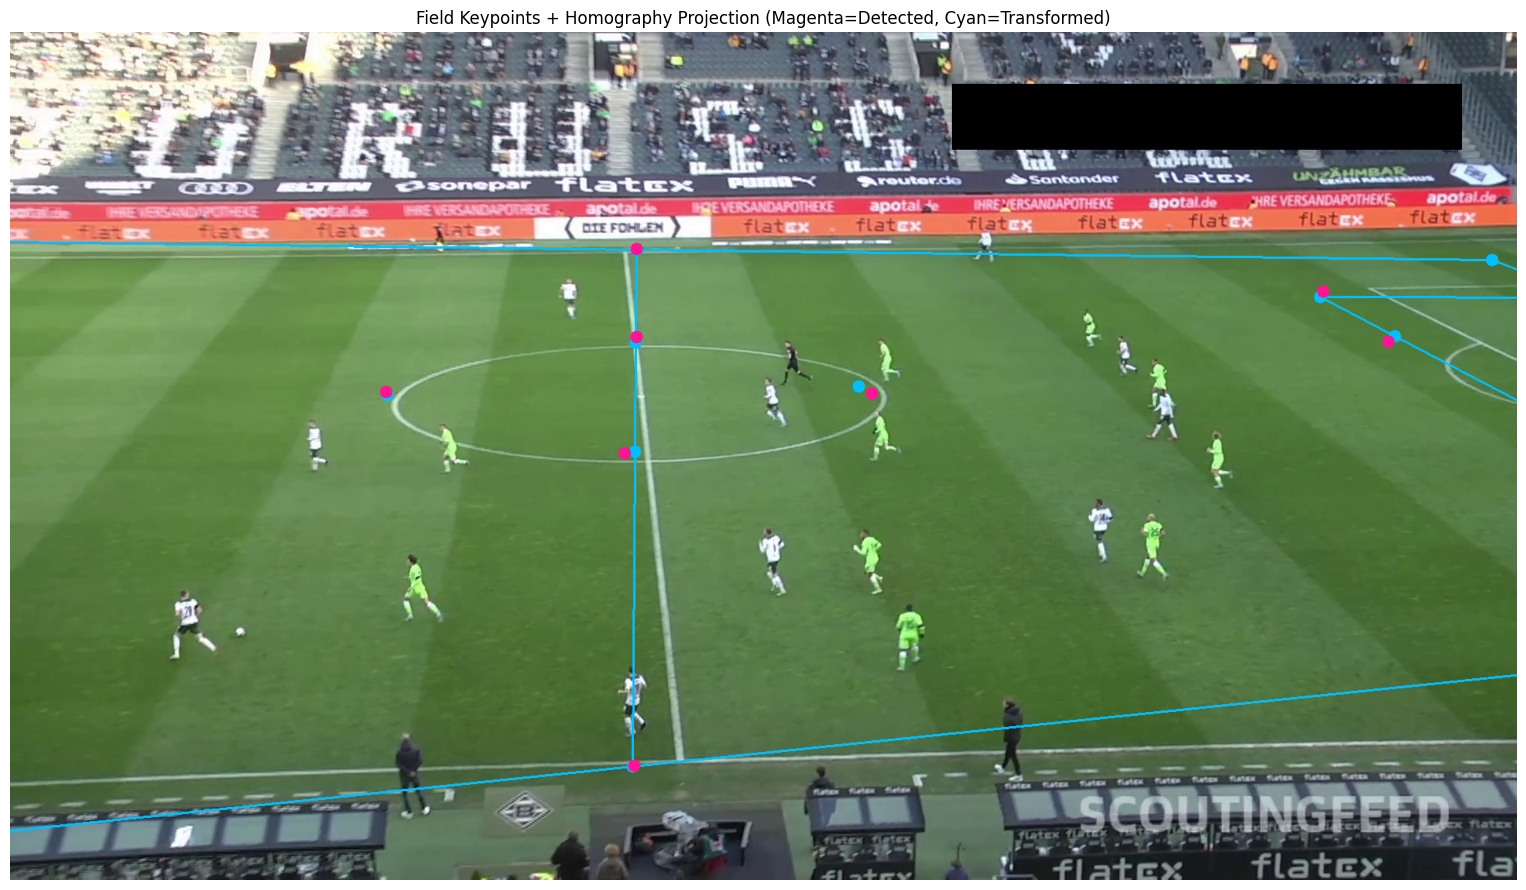

✓ Keypoint visualization complete!


In [15]:
# ============================================================================
# KEYPOINT VISUALIZATION & HOMOGRAPHY
# ============================================================================

# Read a new frame for keypoint visualization
test_frame_generator = sv.get_video_frames_generator(
    source_path=str(VIDEO_PATH),
    start=100
)

test_frame = next(test_frame_generator)

# Create annotators for keypoints
edge_annotator = sv.EdgeAnnotator(
    color=sv.Color.from_hex("#00BFFF"),
    thickness=2,
    edges=PITCH_CONFIG.edges
)

vertex_annotator_detected = sv.VertexAnnotator(
    color=sv.Color.from_hex("#FF1493"),
    radius=8
)

vertex_annotator_transformed = sv.VertexAnnotator(
    color=sv.Color.from_hex("#00BFFF"),
    radius=8
)

# Run field keypoint detection
field_result = FIELD_DETECTION_MODEL(
    test_frame,
    conf=DETECTION_CONFIDENCE,
    device=DEVICE
)[0]

key_points = sv.KeyPoints.from_ultralytics(field_result)

print(f"Detected keypoints shape: {key_points.xy.shape}")

# Filter by confidence
confidence_filter = key_points.confidence[0] > 0.5
frame_reference_points = key_points.xy[0][confidence_filter]
frame_reference_key_points = sv.KeyPoints(xy=frame_reference_points[np.newaxis, ...])

print(f"Filtered keypoints (confidence > 0.5): {len(frame_reference_points)}")

# Get pitch reference points
pitch_reference_points = np.array(PITCH_CONFIG.vertices)[confidence_filter]

# Create homography transformer
if len(frame_reference_points) > 0 and len(pitch_reference_points) > 0:
    transformer_viz = ViewTransformer(
        source=pitch_reference_points,
        target=frame_reference_points
    )
    
    # Transform all pitch vertices
    pitch_all_points = np.array(PITCH_CONFIG.vertices)
    frame_all_points = transformer_viz.transform_points(points=pitch_all_points)
    frame_all_key_points = sv.KeyPoints(xy=frame_all_points[np.newaxis, ...])
    
    # Annotate frame
    keypoint_viz_frame = test_frame.copy()
    
    # Draw pitch edges (cyan)
    keypoint_viz_frame = edge_annotator.annotate(
        scene=keypoint_viz_frame,
        key_points=frame_all_key_points
    )
    
    # Draw transformed pitch vertices (cyan)
    keypoint_viz_frame = vertex_annotator_transformed.annotate(
        scene=keypoint_viz_frame,
        key_points=frame_all_key_points
    )
    
    # Draw detected keypoints (magenta)
    keypoint_viz_frame = vertex_annotator_detected.annotate(
        scene=keypoint_viz_frame,
        key_points=frame_reference_key_points
    )
    
    # Display
    plt.figure(figsize=(16, 9))
    plt.imshow(cv2.cvtColor(keypoint_viz_frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Field Keypoints + Homography Projection (Magenta=Detected, Cyan=Transformed)")
    plt.tight_layout()
    plt.show()
    
    print("✓ Keypoint visualization complete!")
else:
    print("⚠ Not enough keypoints for homography transformation")